<a href="https://colab.research.google.com/github/umiSirya/FUTURE_DS_01/blob/main/sales_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

In [42]:
dp = pd.read_csv('/content/data.csv', encoding='latin1')
dp.head()
dp.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


# **EDA**

In [43]:
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [44]:
#missing values
dp.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [45]:
dp.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [46]:
dp["InvoiceNo"].value_counts()

,count
InvoiceNo,
573585,1114
581219,749
581492,731
580729,721
558475,705
...,...
581483,1
581566,1
C581499,1


In [47]:
# total number of cancelled invoices
n_cancels = dp["InvoiceNo"].astype(str).str.startswith("C").sum()
print(f"\nCancellation rows (InvoiceNo starts with 'C'): {n_cancels:,}")


Cancellation rows (InvoiceNo starts with 'C'): 9,288


In [48]:
#count the quatities whose values are 0 or negative
(dp['Quantity'] <= 0).sum()



np.int64(10624)

In [49]:
#count prices whose values are 0 or negative
(dp['UnitPrice'] <= 0).sum()

np.int64(2517)

# **Cleaning**

In [50]:
 # change the dtype of invoice date column
dp["InvoiceDate"] = pd.to_datetime(dp["InvoiceDate"])

In [51]:
# remove caancelled invoices

cancelled_invoices = dp["InvoiceNo"].astype(str).str.startswith("C")
dp = dp[~cancelled_invoices]
print(f"Removed {cancelled_invoices.sum():,} cancellation rows")

Removed 9,288 cancellation rows


In [52]:
# remove invalid unit price
raw_rows = len(dp)

dp = dp[(dp["Quantity"] > 0) & (dp["UnitPrice"] > 0)]
print(f"Removed {raw_rows - len(dp):,} rows with invalid UnitPrice")

Removed 2,517 rows with invalid UnitPrice


In [53]:
 # Derived columns

dp["Revenue"]      = dp["Quantity"] * dp["UnitPrice"]
dp["YearMonth"]    = dp["InvoiceDate"].dt.to_period("M")
dp["DayOfWeek"]    = dp["InvoiceDate"].dt.day_name()
dp["Hour"]         = dp["InvoiceDate"].dt.hour


In [54]:
# 'confirming the columns present in dataset
dp.columns.tolist()


['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country',
 'Revenue',
 'YearMonth',
 'DayOfWeek',
 'Hour']

In [55]:
print(f"\nClean dataset: {len(dp):,} rows")
print(f"Date range: {dp['InvoiceDate'].min().date()} → {dp['InvoiceDate'].max().date()}")
print(f"Total revenue: £{dp['Revenue'].sum():,.0f}")


Clean dataset: 530,104 rows
Date range: 2010-12-01 → 2011-12-09
Total revenue: £10,666,685


In [56]:
# putting the cleanned data to a csv file

dp.to_csv("clean_retail.csv", index=False)


# **Visualizations**

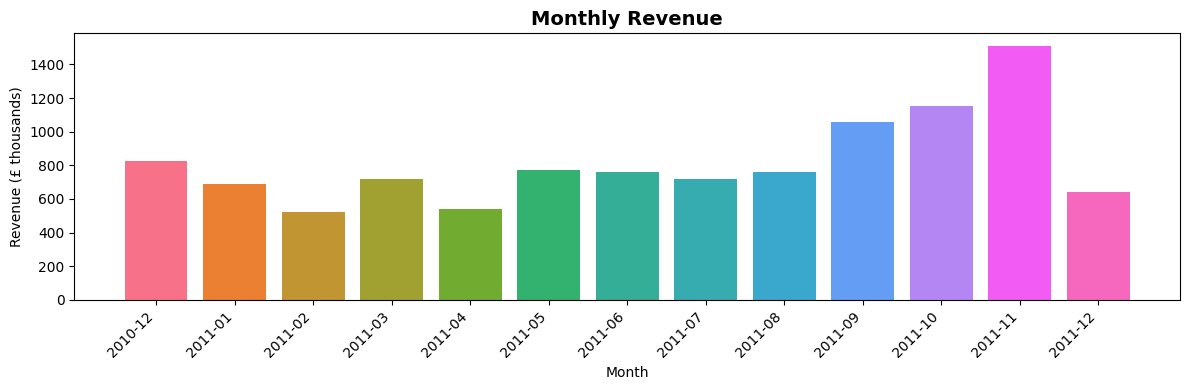

In [57]:
# Monthly Revenue
PALETTE = "husl"

monthly = dp.groupby("YearMonth")["Revenue"].sum().reset_index()
monthly["YearMonth"] = monthly["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly["YearMonth"], monthly["Revenue"] / 1e3,
       color=sns.color_palette(PALETTE, len(monthly)))
ax.set_title("Monthly Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (£ thousands)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

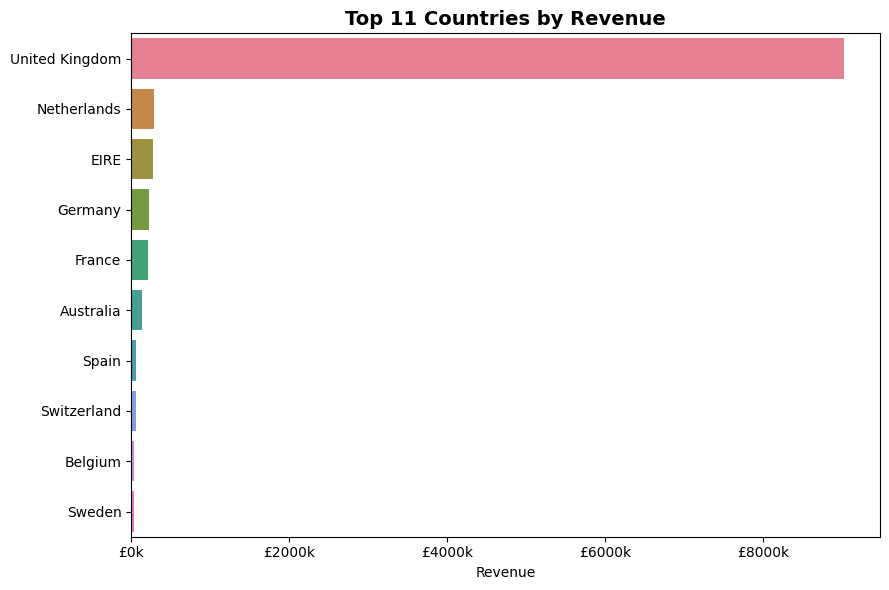

In [58]:
# Top 10 Countries by Revenue (including UK)

top_countries = (dp.groupby("Country")["Revenue"].sum()
                 .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_countries, y="Country", x="Revenue",
            hue="Country", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 11 Countries by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

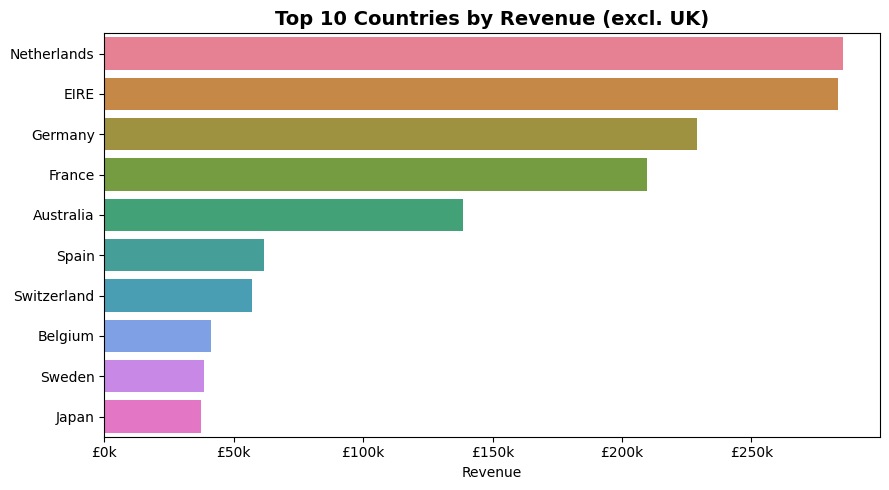

In [59]:
# Top 10 Countries by Revenue (excluding UK)

top_countries = (dp[dp["Country"] != "United Kingdom"]
                 .groupby("Country")["Revenue"].sum()
                 .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_countries, y="Country", x="Revenue",
            hue="Country", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 10 Countries by Revenue (excl. UK)", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

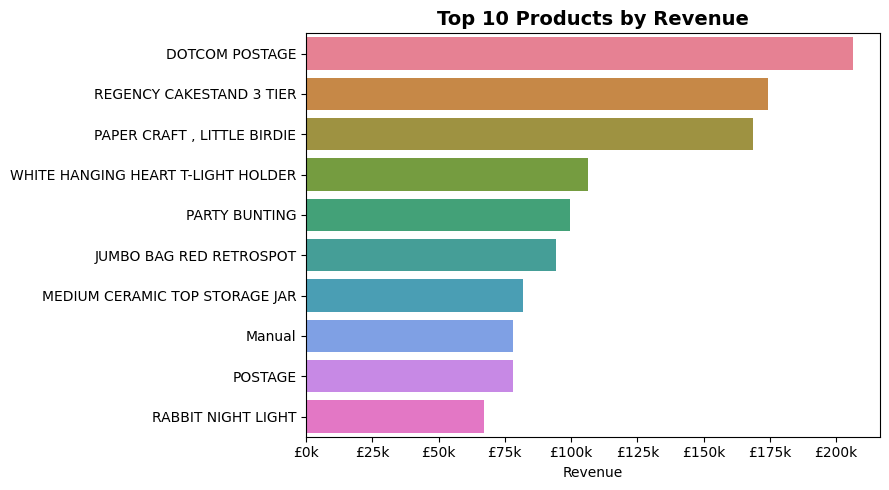

In [60]:
# Top 10 products by revenue

top_products = (dp.groupby("Description")["Revenue"].sum()
                  .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_products, y="Description", x="Revenue",
            hue="Description", palette=PALETTE, legend=False, ax=ax)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"£{x/1e3:.0f}k"))
ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

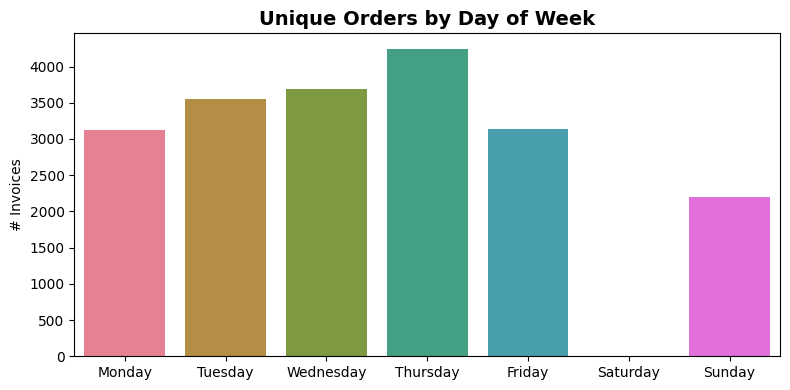

In [61]:
# Orders by days of the week

DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = (dp.groupby("DayOfWeek")["InvoiceNo"]
         .nunique()
         .reindex(DOW_ORDER)
         .reset_index())
dow.columns = ["DayOfWeek", "Orders"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=dow, x="DayOfWeek", y="Orders",
            hue="DayOfWeek", palette=PALETTE, legend=False, ax=ax)
ax.set_title("Unique Orders by Day of Week", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("# Invoices")
plt.tight_layout()
plt.show()

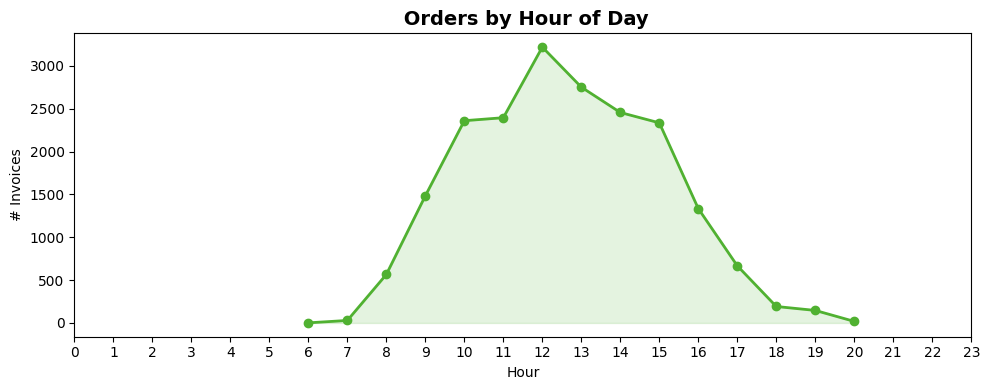

In [62]:
# Orders by Hour of Day

hourly = dp.groupby("Hour")["InvoiceNo"].nunique().reset_index()
hourly.columns = ["Hour", "Orders"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hourly["Hour"], hourly["Orders"], marker="o",
        color=sns.color_palette(PALETTE)[2], linewidth=2)
ax.fill_between(hourly["Hour"], hourly["Orders"],
                alpha=0.15, color=sns.color_palette(PALETTE)[2])
ax.set_title(" Orders by Hour of Day", fontsize=14, fontweight="bold")
ax.set_xlabel("Hour")
ax.set_ylabel("# Invoices")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

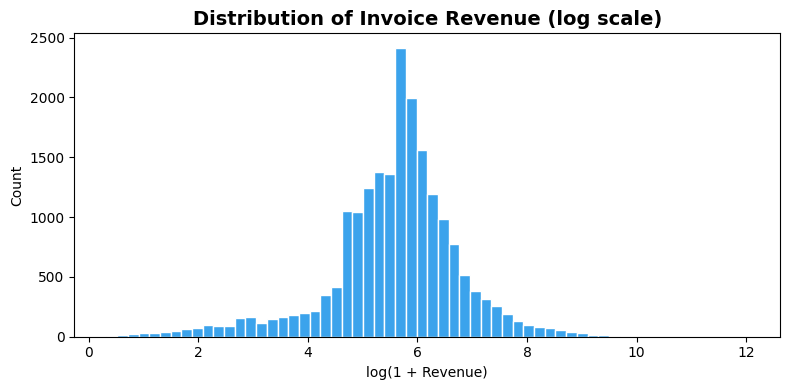

In [63]:
# Revenue distribution

fig, ax = plt.subplots(figsize=(8, 4))
invoice_rev = dp.groupby("InvoiceNo")["Revenue"].sum()
ax.hist(np.log1p(invoice_rev), bins=60,
        color=sns.color_palette(PALETTE)[4], edgecolor="white")
ax.set_title("Distribution of Invoice Revenue (log scale)", fontsize=14, fontweight="bold")
ax.set_xlabel("log(1 + Revenue)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

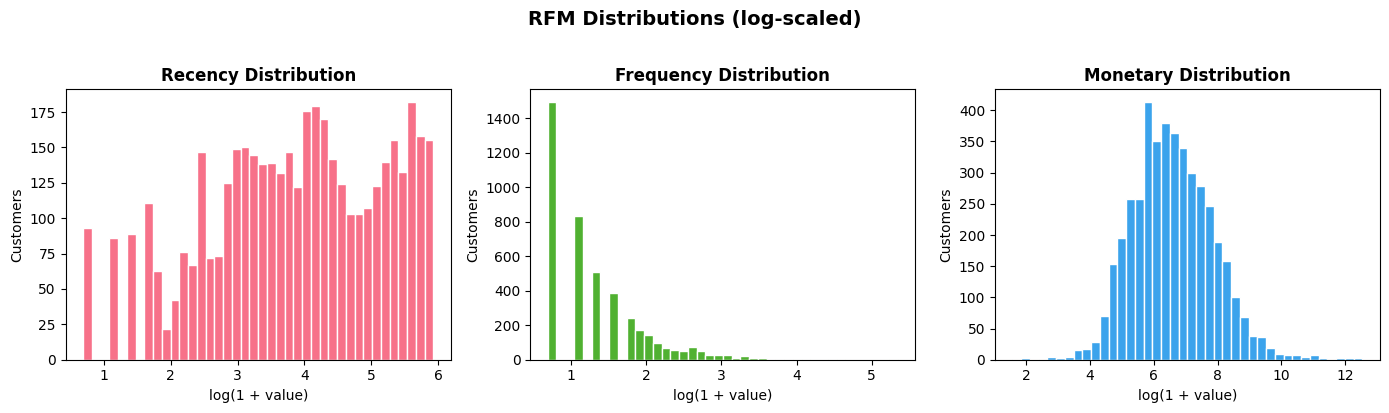

In [64]:
# RFM Analysis

snapshot = dp["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = dp.groupby("CustomerID").agg(
    Recency   = ("InvoiceDate",  lambda x: (snapshot - x.max()).days),
    Frequency = ("InvoiceNo",    "nunique"),
    Monetary  = ("Revenue",      "sum")
).reset_index()

# Score 1-5 (use rank-based scoring to handle ties)
for col in ["Recency", "Frequency", "Monetary"]:
    ascending = col != "Recency"   # lower recency = better
    rfm[f"{col}_Score"] = pd.qcut(
        rfm[col].rank(method="first", ascending=ascending),
        q=5, labels=[1,2,3,4,5], duplicates="drop"
    )

rfm["RFM_Score"] = (rfm["Recency_Score"].astype(int) +
                    rfm["Frequency_Score"].astype(int) +
                    rfm["Monetary_Score"].astype(int))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color_idx in zip(axes,
        ["Recency", "Frequency", "Monetary"],
        [0, 2, 4]):
    val = rfm[col]
    ax.hist(np.log1p(val), bins=40,
            color=sns.color_palette(PALETTE)[color_idx], edgecolor="white")
    ax.set_title(f"{col} Distribution", fontweight="bold")
    ax.set_xlabel("log(1 + value)")
    ax.set_ylabel("Customers")

plt.suptitle("RFM Distributions (log-scaled)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

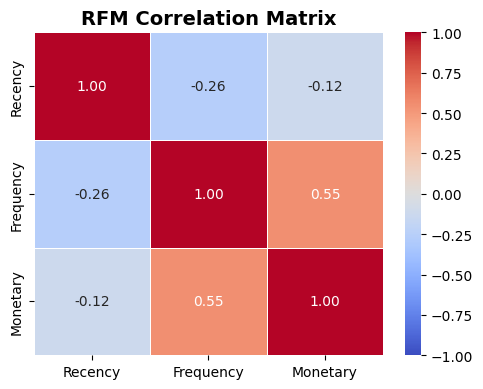

In [65]:
# Correlation heatmap

corr = rfm[["Recency","Frequency","Monetary"]].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("RFM Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [66]:
# Summary

print("\n" + "=" * 60)
print("5. KEY METRICS (clean data)")
print("=" * 60)
print(f"  Total revenue      : £{dp['Revenue'].sum():>12,.0f}")
print(f"  Unique customers   : {dp['CustomerID'].nunique():>12,}")
print(f"  Unique invoices    : {dp['InvoiceNo'].nunique():>12,}")
print(f"  Unique products    : {dp['StockCode'].nunique():>12,}")
print(f"  Avg order value    : £{dp.groupby('InvoiceNo')['Revenue'].sum().mean():>12.2f}")
print(f"  Avg items per order: {dp.groupby('InvoiceNo')['Quantity'].sum().mean():>12.1f}")



5. KEY METRICS (clean data)
  Total revenue      : £  10,666,685
  Unique customers   :        4,338
  Unique invoices    :       19,960
  Unique products    :        3,922
  Avg order value    : £      534.40
  Avg items per order:        280.0
